### 1 Setup

#### Import Libraries

In [1]:
# Data manipulation libraries.
import numpy as np
import pandas as pd

# Data visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Data modeling libraries.
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

#### Configure Libraries

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100
pd.options.display.max_columns = None

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

#### Import Dataset

In [3]:
# !gdown 16KtxSt_QEGQvfluEaMls5cCHPwhRXgCk
# https://drive.google.com/uc?id=16KtxSt_QEGQvfluEaMls5cCHPwhRXgCk

# https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset
emp_df = pd.read_csv("data/employee_attrition_kaggle_dataset.csv")

display(emp_df.sample(5, random_state=rng))
row_count, col_count = emp_df.shape
print(f"Dataset contains {row_count} rows and {col_count} columns.")

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
771,772,42,Female,Single,IT,Manager,3,3060,29,28,12,9,3,1,1,95,No,2,58,5,1,2,1,29,2,No
438,439,22,Male,Divorced,Finance,Manager,5,14594,50,8,7,4,1,5,3,19,Yes,6,42,9,2,2,4,1,2,Yes
653,654,38,Female,Single,HR,Manager,1,6199,26,20,11,2,1,4,3,15,No,5,32,7,4,2,1,16,2,No
88,89,54,Female,Married,IT,Analyst,3,17389,40,12,7,5,1,3,4,78,No,1,46,6,4,2,4,21,2,No
433,434,54,Female,Single,Finance,Analyst,5,14664,53,28,4,9,1,4,1,8,Yes,7,55,0,1,4,4,16,3,Yes


Dataset contains 1000 rows and 26 columns.


#### Objective

1. Perform EDA
2. Train test split
3. Apply cross validation
4. Hyperparameter Tuning
5. Evaluate on testing set

### 2 EDA

#### Metadata

In [4]:
emp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    1000 non-null   int64
 1   Age                            1000 non-null   int64
 2   Gender                         1000 non-null   str  
 3   Marital_Status                 1000 non-null   str  
 4   Department                     1000 non-null   str  
 5   Job_Role                       1000 non-null   str  
 6   Job_Level                      1000 non-null   int64
 7   Monthly_Income                 1000 non-null   int64
 8   Hourly_Rate                    1000 non-null   int64
 9   Years_at_Company               1000 non-null   int64
 10  Years_in_Current_Role          1000 non-null   int64
 11  Years_Since_Last_Promotion     1000 non-null   int64
 12  Work_Life_Balance              1000 non-null   int64
 13  Job_Satisfaction              

#### Target Variable

In [35]:
emp_df["Attrition"].value_counts(normalize=True).round(2)

Attrition
0    0.81
1    0.19
Name: proportion, dtype: float64

Dataset is highly imbalanced with:
- 81% Negative class-labels (No Attrition)
- 20% Positive class-labels (Attrition)

#### Cardinality

In [5]:
emp_df.nunique().sort_values(ascending=False)

Employee_ID                      1000
Monthly_Income                    971
Training_Hours_Last_Year          100
Hourly_Rate                        85
Distance_From_Home                 49
Age                                40
Average_Hours_Worked_Per_Week      30
Years_at_Company                   29
Absenteeism                        20
Years_in_Current_Role              14
Years_Since_Last_Promotion         10
Project_Count                       9
Department                          5
Job_Level                           5
Job_Satisfaction                    5
Relationship_with_Manager           4
Job_Role                            4
Performance_Rating                  4
Number_of_Companies_Worked          4
Job_Involvement                     4
Work_Life_Balance                   4
Work_Environment_Satisfaction       4
Marital_Status                      3
Gender                              2
Overtime                            2
Attrition                           2
dtype: int64

#### Drop unwanted columns

In [6]:
emp_df.drop(columns=["Employee_ID"], inplace=True)

In [7]:
# corr = emp_df.corr(numeric_only=True, method="spearman").round(2)

# plt.figure(figsize=(13, 9))
# sns.heatmap(corr, cmap="YlGnBu", linecolor="white", linewidth=0.5, vmin=-1, vmax=1, annot=True)
# plt.title("Correlation Matrix")
# plt.xticks(rotation=90)

# plt.show()

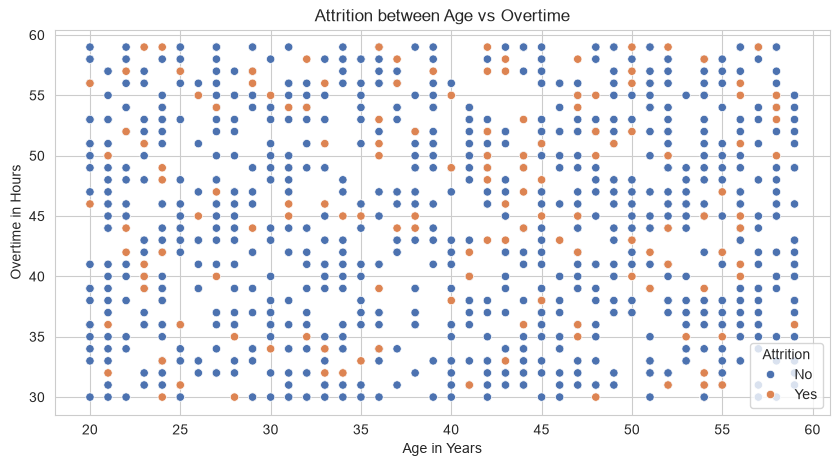

In [8]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=emp_df, x="Age", y="Average_Hours_Worked_Per_Week", hue="Attrition")
plt.title("Attrition between Age vs Overtime")
plt.xlabel("Age in Years")
plt.ylabel("Overtime in Hours")

plt.show()

### 3 Feature Encoding

In [9]:
non_num_cols = emp_df.select_dtypes(exclude=["number"]).columns.tolist()
non_num_cols

['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', 'Attrition']

Encoding strategy:

```
Attrition      | Label
Overtime       | Label
Gender         | TargetEncoding  | Avoid OneHot for Tree based models
Marital_Status | TargetEncoding
Department     | Ordinal
Job_Role       | Ordinal
```

#### Feature `Attrition`

In [10]:
emp_df["Attrition"].value_counts()

Attrition
No     811
Yes    189
Name: count, dtype: int64

In [11]:
emp_df["Attrition"] = emp_df["Attrition"].map(
    {
        "Yes": 1,
        "No": 0,
    }
)
emp_df["Attrition"].value_counts()

Attrition
0    811
1    189
Name: count, dtype: int64

#### Feature `Overtime`

In [12]:
emp_df["Overtime"].value_counts()

Overtime
No     512
Yes    488
Name: count, dtype: int64

In [13]:
emp_df["Overtime"] = emp_df["Overtime"].map(
    {
        "Yes": 1,
        "No": 0,
    }
)
emp_df["Overtime"].value_counts()

Overtime
0    512
1    488
Name: count, dtype: int64

#### Feature `Gender`

In [14]:
emp_df["Gender"].value_counts()

Gender
Male      516
Female    484
Name: count, dtype: int64

In [15]:
# oh_en = OneHotEncoder(sparse_output=False)
# emp_df[oh_en.get_feature_names_out()] = oh_en.fit_transform(emp_df[["Gender"]])
# emp_df.drop(columns=["Gender"], inplace=True)
# emp_df[oh_en.get_feature_names_out()].sample(3, random_state=rng)

In [16]:
tgt_en1 = TargetEncoder(target_type="binary")
emp_df[["Gender"]] = tgt_en1.fit_transform(X=emp_df[["Gender"]], y=emp_df["Attrition"])

#### Feature `Marital_Status`

In [17]:
emp_df["Marital_Status"].value_counts()

Marital_Status
Married     348
Single      339
Divorced    313
Name: count, dtype: int64

In [18]:
tgt_en2 = TargetEncoder(target_type="binary")
emp_df[["Marital_Status"]] = tgt_en2.fit_transform(X=emp_df[["Marital_Status"]], y=emp_df["Attrition"])

#### Feature `Department`

In [19]:
emp_df["Department"].value_counts()

Department
Finance      218
HR           211
Sales        199
Marketing    198
IT           174
Name: count, dtype: int64

In [20]:
emp_df["Department"] = emp_df["Department"].map(
    {
        "HR": 1,
        "Finance": 2,
        "Marketing": 3,
        "Sales": 4,
        "IT": 5,
    }
)

#### Feature `Job_Role`

In [21]:
emp_df["Job_Role"].value_counts()

Job_Role
Manager      268
Executive    252
Analyst      251
Assistant    229
Name: count, dtype: int64

In [22]:
emp_df["Job_Role"] = emp_df["Job_Role"].map(
    {
        "Assistant": 1,
        "Analyst": 2,
        "Manager": 3,
        "Executive": 4,
    }
)

In [23]:
emp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1000 non-null   int64  
 1   Gender                         1000 non-null   float64
 2   Marital_Status                 1000 non-null   float64
 3   Department                     1000 non-null   int64  
 4   Job_Role                       1000 non-null   int64  
 5   Job_Level                      1000 non-null   int64  
 6   Monthly_Income                 1000 non-null   int64  
 7   Hourly_Rate                    1000 non-null   int64  
 8   Years_at_Company               1000 non-null   int64  
 9   Years_in_Current_Role          1000 non-null   int64  
 10  Years_Since_Last_Promotion     1000 non-null   int64  
 11  Work_Life_Balance              1000 non-null   int64  
 12  Job_Satisfaction               1000 non-null   int64  
 13  

### 4 Training Setup

#### Train test split

In [24]:
X = emp_df[emp_df.columns.difference(["Attrition"])]
# X = emp_df[emp_df.columns.difference(non_num_cols)]
y = emp_df["Attrition"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 24), (200, 24), (800,), (200,))

In [26]:
y_train.value_counts(normalize=True).mul(100).round(2)

Attrition
0    81.12
1    18.88
Name: proportion, dtype: float64

In [27]:
y_test.value_counts(normalize=True).mul(100).round(2)

Attrition
0    81.0
1    19.0
Name: proportion, dtype: float64

### 5 K-Fold Cross validation

#### Base Model

In [28]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [29]:
model1 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Training Accuracy

In [30]:
model1.score(X_train, y_train)

1.0

In [31]:
# Perform Cross Validation
scores = cross_val_score(model1, X_train, y_train, cv=kf, scoring="accuracy")
scores

array([0.675  , 0.60625, 0.65   , 0.6875 , 0.74375])

#### Feature Importance

In [32]:
fi_df = pd.DataFrame(
    {
        "Feature": model1.feature_names_in_,
        "Importance": model1.feature_importances_.round(2),
    }
).sort_values(by="Importance", ascending=False, ignore_index=True)
fi_df

,Feature,Importance
0,Monthly_Income,0.12
1,Age,0.08
2,Distance_From_Home,0.07
3,Job_Role,0.06
4,Years_at_Company,0.06
5,Years_in_Current_Role,0.06
6,Hourly_Rate,0.05
7,Years_Since_Last_Promotion,0.05
8,Marital_Status,0.05
9,Training_Hours_Last_Year,0.05


### 6 Hyperparameter Tuning

### 7 Model Evaluation

#### Testing Accuracy

In [33]:
model1.score(X_test, y_test)

0.685